# Ranking models, and choosing a threshold on purpose

Notebook 2 ended on an awkward fact: every metric we computed depended on a
threshold, and the threshold was a habit rather than a decision.

This notebook does three things about that.

1. Builds the **receiver operating characteristic (ROC) curve**, the standard
   way to compare classifiers without committing to a threshold, and the **area
   under the curve (AUC)** that summarises it — including what that area
   actually means, verified by experiment rather than asserted.
2. Shows where ROC quietly misleads. On a rare-positive problem it can look
   excellent while the model is unusable, and we will make that happen on
   purpose.
3. Chooses a threshold from **costs**, which is the only defensible way to
   choose one.

Then a short section on what changes when there are more than two classes.

In [1]:
# pip install numpy==1.26.4 pandas==2.1.1 matplotlib==3.8.0 scikit-learn==1.3.1

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (ConfusionMatrixDisplay, average_precision_score,
                             classification_report, confusion_matrix,
                             precision_recall_curve, precision_score,
                             recall_score, roc_auc_score, roc_curve)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

from disk_data import load_drives, load_multiclass, transform_features

FIGURES = Path.cwd().parent / "Figures"
FIGURES.mkdir(exist_ok=True)

BLUE, TEAL, RUST, GOLD = "#1F4E79", "#2E7D8A", "#9C4221", "#F0BE50"
INK, SLATE = "#1A1A1A", "#4A5568"
plt.rcParams.update({
    "font.size": 11, "axes.edgecolor": SLATE, "axes.labelcolor": INK,
    "text.color": INK, "xtick.color": SLATE, "ytick.color": SLATE,
})

drives = load_drives()
X, y = transform_features(drives), drives["failed"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)

model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2_000))
model.fit(X_train, y_train)
probability = model.predict_proba(X_test)[:, 1]

print(f"{len(y_test):,} test drives, {int(y_test.sum())} failures")

2,000 test drives, 76 failures


## 1. The ROC curve, built by hand

The curve plots two rates against each other as the threshold sweeps from 1 down
to 0:

$$\text{TPR} = \frac{TP}{TP + FN} \qquad\qquad \text{FPR} = \frac{FP}{FP + TN}$$

The **true positive rate (TPR)** is recall under another name — the fraction of
failing drives we catch. The **false positive rate (FPR)** is the fraction of
healthy drives we wrongly condemn.

**The intuition.** Both rates start at 0 when the threshold is 1 — flag nothing,
catch nothing, disturb nobody — and both reach 1 when the threshold is 0. The
question is *the order in which they get there*. A good model raises TPR fast
while FPR is still low, because its highest scores really are the failures. A
useless model raises them together, and traces the diagonal.

So the ROC curve asks: **as we grow more willing to raise alarms, do we catch
failures faster than we annoy technicians?**

The name is wartime radar: operators tuning receivers to detect aircraft
without chasing flocks of birds. The problem is the same shape.

In [2]:
def roc_by_hand(labels, scores):
    """Sweep every distinct score as a threshold and count."""
    labels = np.asarray(labels)
    positives, negatives = labels.sum(), (1 - labels).sum()
    tpr_points, fpr_points = [], []
    for threshold in np.r_[1.1, np.sort(np.unique(scores))[::-1]]:
        flagged = scores >= threshold
        tpr_points.append((flagged & (labels == 1)).sum() / positives)
        fpr_points.append((flagged & (labels == 0)).sum() / negatives)
    return np.array(fpr_points), np.array(tpr_points)


fpr_hand, tpr_hand = roc_by_hand(y_test, probability)
fpr, tpr, thresholds = roc_curve(y_test, probability)

# The area under our own curve, by the trapezoidal rule.
area_by_hand = np.trapz(tpr_hand, fpr_hand)

print(f"points on our curve: {len(fpr_hand)}   on scikit-learn's: {len(fpr)}")
print("(scikit-learn drops points that lie on a straight segment)\n")
print(f"area under our curve : {area_by_hand:.4f}")
print(f"roc_auc_score        : {roc_auc_score(y_test, probability):.4f}")

points on our curve: 2001   on scikit-learn's: 72
(scikit-learn drops points that lie on a straight segment)

area under our curve : 0.9493
roc_auc_score        : 0.9493


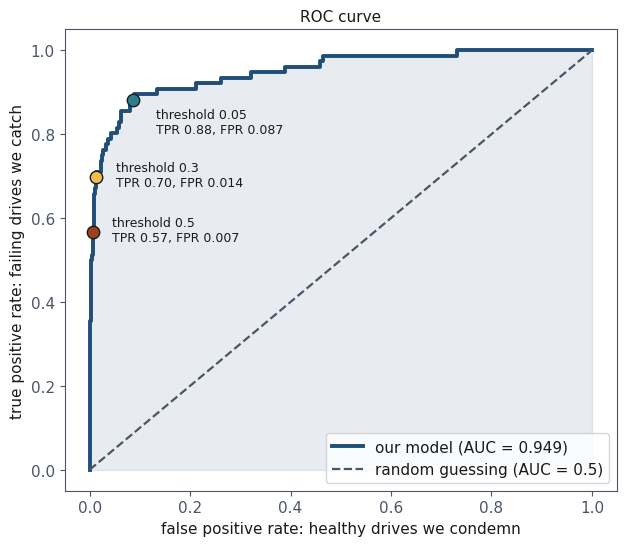

In [3]:
fig, ax = plt.subplots(figsize=(6.4, 5.6))
ax.plot(fpr, tpr, lw=2.8, color=BLUE, label=f"our model (AUC = {roc_auc_score(y_test, probability):.3f})")
ax.plot([0, 1], [0, 1], ls="--", lw=1.6, color=SLATE, label="random guessing (AUC = 0.5)")
ax.fill_between(fpr, tpr, alpha=.10, color=BLUE)

for threshold, colour, label_offset in ((0.5, RUST, (14, -6)),
                                       (0.3, GOLD, (14, -6)),
                                       (0.05, TEAL, (16, -24))):
    index = int(np.argmin(np.abs(thresholds - threshold)))
    ax.scatter(fpr[index], tpr[index], s=80, color=colour, edgecolor=INK, zorder=5)
    ax.annotate(f"threshold {threshold:g}\nTPR {tpr[index]:.2f}, FPR {fpr[index]:.3f}",
                (fpr[index], tpr[index]), textcoords="offset points",
                xytext=label_offset, fontsize=9)

ax.set_xlabel("false positive rate: healthy drives we condemn")
ax.set_ylabel("true positive rate: failing drives we catch")
ax.set_title("ROC curve", fontsize=11)
ax.legend(loc="lower right")
fig.tight_layout()
fig.savefig(FIGURES / "roc_curve.png", dpi=150, bbox_inches="tight",
            facecolor="white")
plt.show()

The three marked points are the same three thresholds from notebook 2, now on
one curve. Moving along it does not change the model — only the rule.

The perfect classifier goes straight up the left edge and along the top: catch
everything, disturb nobody. The diagonal is a coin flip. **Everything real lives
in between, and AUC measures how far towards the corner you got.**

## 2. What AUC actually means

The area under a curve is a geometric fact, not an interpretation. The
interpretation is this, and it is remarkably clean:

> **AUC is the probability that the model gives a higher score to a randomly
> chosen failing drive than to a randomly chosen healthy one.**

An AUC of 0.949 says: pick one drive that failed and one that did not, at
random; 95 times out of 100 the model scored the failing one higher.

That makes AUC a measure of **ranking quality**, not of calibration and not of
any particular decision. It is threshold-free because ranking is threshold-free.

We do not have to take that on faith. Draw the pairs and count.

In [4]:
rng = np.random.default_rng(0)
failing_scores = probability[y_test.to_numpy() == 1]
healthy_scores = probability[y_test.to_numpy() == 0]

draws = 200_000
wins = (failing_scores[rng.integers(0, len(failing_scores), draws)]
        > healthy_scores[rng.integers(0, len(healthy_scores), draws)])

print(f"drew {draws:,} random (failing, healthy) pairs")
print(f"  the failing drive scored higher in {wins.mean():.4f} of them")
print(f"  roc_auc_score says                 {roc_auc_score(y_test, probability):.4f}")
print(f"  difference                         {abs(wins.mean() - roc_auc_score(y_test, probability)):.4f}")

drew 200,000 random (failing, healthy) pairs
  the failing drive scored higher in 0.9488 of them
  roc_auc_score says                 0.9493
  difference                         0.0005


Two independent routes to the same number, agreeing to three decimal places.
The remaining gap is sampling noise in our 200,000 draws, and it shrinks if you
draw more.

**A consequence worth stating**, because it is the source of a common confusion:
AUC does not care what your probabilities *are*, only how they *order*. Divide
every predicted probability by 10 and the AUC is unchanged, while the model
becomes badly calibrated and every threshold-based decision changes. AUC is a
good summary of ranking and says nothing about whether "0.7" means anything.

## 3. Where ROC misleads: the rare-positive trap

AUC of 0.949 sounds like a finished project. Now watch what happens when the
positives get rarer — which, in fraud, disease and hardware failure, is the
direction reality moves.

We keep the same model, keep every healthy drive in a fleet of 60,000, and thin
the *failures* until they are 0.4% of the fleet instead of 3.8%. The model is
**not retrained** and the drives it sees are drives it would have seen anyway.
Nothing about its ranking ability changes.

In [5]:
big = load_drives(n_samples=60_000, random_state=7)
X_big, y_big = transform_features(big), big["failed"]
score_big = model.predict_proba(X_big)[:, 1]

failing_index = np.flatnonzero(y_big.to_numpy() == 1)
healthy_index = np.flatnonzero(y_big.to_numpy() == 0)


def fleet_at_rate(target_rate, seed=3):
    """Every healthy drive, plus enough failures to hit `target_rate`."""
    n_failing = int(round(len(healthy_index) * target_rate / (1 - target_rate)))
    n_failing = min(n_failing, len(failing_index))
    keep = np.r_[healthy_index,
                 np.random.default_rng(seed).choice(failing_index, n_failing,
                                                    replace=False)]
    return y_big.to_numpy()[keep], score_big[keep]


rows = []
for target_rate in (0.038, 0.010, 0.004):
    labels, scores = fleet_at_rate(target_rate)
    flagged = (scores >= 0.5).astype(int)
    rows.append({
        "positive rate": labels.mean(),
        "failures": int(labels.sum()),
        "AUC": roc_auc_score(labels, scores),
        "avg precision": average_precision_score(labels, scores),
        "precision @0.5": precision_score(labels, flagged, zero_division=0),
        "recall @0.5": recall_score(labels, flagged),
    })

print(pd.DataFrame(rows).to_string(index=False,
                                   float_format=lambda v: f"{v:.4f}"))

 positive rate  failures    AUC  avg precision  precision @0.5  recall @0.5
        0.0380      2274 0.9677         0.7062          0.7876       0.4956
        0.0100       582 0.9654         0.4875          0.4619       0.4485
        0.0040       231 0.9735         0.3608          0.2585       0.4589


Read the `AUC` column and then the `precision @0.5` column.

**AUC hardly moves** — 0.968, 0.965, 0.974. It is a property of the ranking, and
thinning the failures at random does not change how well the model ranks. It
keeps reporting an excellent model, and at the rarest setting it reports a
slightly *better* one, which is sampling noise on 231 positives rather than a
real improvement.

**Precision collapses**, from 0.79 to 0.26 — a third of what it was, at the same
threshold, with the same model. Average precision falls by half. That is the
number the technician experiences: two alarms in three are now false, and AUC
said nothing had changed.

The reason is in the denominators. FPR divides false positives by the number of
healthy drives, which is enormous and growing — so 1,000 false alarms among
100,000 healthy drives is an FPR of 0.01, invisible on the ROC axis. Precision
divides those same 1,000 false alarms by the alarms raised, where they dominate.

**This is the second predictable mistake of the lesson**, and again the instinct
is sound: AUC is threshold-free, comparable across models, and bounded in
[0.5, 1] — all genuinely good properties. It simply answers a question about
ranking when the question you had was about the alarms you will actually act
on.

**The rule: on an imbalanced problem, report the precision-recall curve
alongside AUC, never instead of it.**

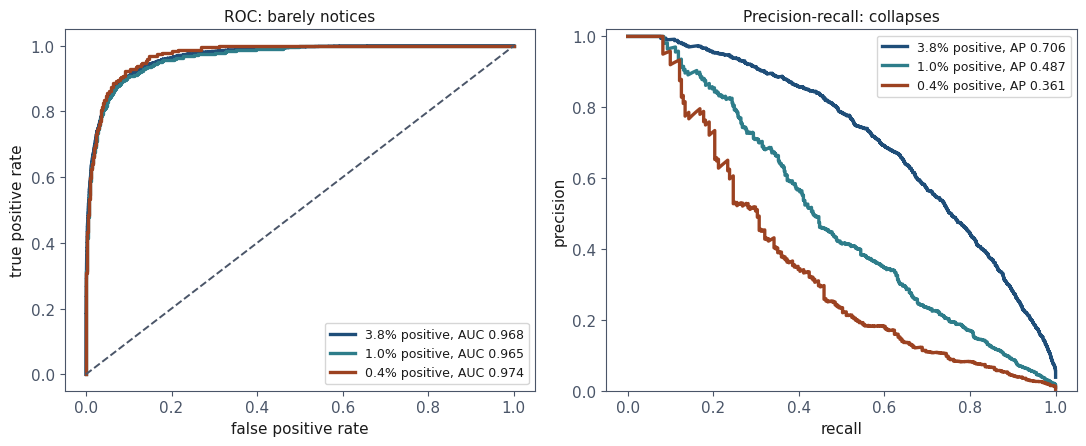

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))
for target_rate, colour in ((0.038, BLUE), (0.010, TEAL), (0.004, RUST)):
    labels, scores = fleet_at_rate(target_rate)

    f, t, _ = roc_curve(labels, scores)
    axes[0].plot(f, t, lw=2.4, color=colour,
                 label=f"{labels.mean():.1%} positive, AUC {roc_auc_score(labels, scores):.3f}")

    p, r, _ = precision_recall_curve(labels, scores)
    axes[1].plot(r, p, lw=2.4, color=colour,
                 label=f"{labels.mean():.1%} positive, AP {average_precision_score(labels, scores):.3f}")

axes[0].plot([0, 1], [0, 1], ls="--", lw=1.4, color=SLATE)
axes[0].set_xlabel("false positive rate"); axes[0].set_ylabel("true positive rate")
axes[0].set_title("ROC: barely notices", fontsize=11)
axes[0].legend(loc="lower right", fontsize=9)

axes[1].set_xlabel("recall"); axes[1].set_ylabel("precision")
axes[1].set_title("Precision-recall: collapses", fontsize=11)
axes[1].set_ylim(0, 1.02); axes[1].legend(loc="upper right", fontsize=9)

fig.tight_layout()
fig.savefig(FIGURES / "roc_vs_pr_imbalance.png", dpi=150, bbox_inches="tight",
            facecolor="white")
plt.show()

Three models that are in fact **one model**, drawn twice. On the left the curves
sit almost on top of each other; on the right they are in different worlds.

## 4. Choosing the threshold from costs

Everything so far describes trade-offs. Choosing a point on the curve needs one
extra ingredient that no metric can supply: **what the two errors cost.**

Put numbers on it for this fleet. They are made up, but the shape of the answer
is not:

- **False positive** — we replace a healthy drive: €140 for the drive plus a
  technician's time.
- **False negative** — a drive fails in service: €2,600 for the emergency
  callout, the rebuild, and the risk while the array is degraded.

A missed failure costs **about nineteen times** a needless replacement. Once
that ratio is written down, the threshold stops being a matter of taste.

In [7]:
COST_FALSE_POSITIVE = 140
COST_FALSE_NEGATIVE = 2_600

grid = np.linspace(0.005, 0.95, 300)
total_cost = []
for threshold in grid:
    flagged = (probability >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, flagged).ravel()
    total_cost.append(fp * COST_FALSE_POSITIVE + fn * COST_FALSE_NEGATIVE)

total_cost = np.array(total_cost)
best_threshold = grid[int(np.argmin(total_cost))]

default_flagged = (probability >= 0.5).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test, default_flagged).ravel()
default_cost = fp * COST_FALSE_POSITIVE + fn * COST_FALSE_NEGATIVE

best_flagged = (probability >= best_threshold).astype(int)
tn_b, fp_b, fn_b, tp_b = confusion_matrix(y_test, best_flagged).ravel()

nothing_cost = int(y_test.sum()) * COST_FALSE_NEGATIVE

print(f"do nothing        : {nothing_cost:>8,} EUR   "
      f"({int(y_test.sum())} failures, all missed)")
print(f"threshold 0.50    : {default_cost:>8,} EUR   FP {fp:>3}  FN {fn:>3}")
print(f"threshold {best_threshold:.2f}    : {total_cost.min():>8,} EUR   "
      f"FP {fp_b:>3}  FN {fn_b:>3}")
print(f"\nchoosing the threshold on purpose saves "
      f"{default_cost - total_cost.min():,} EUR on 2,000 drives "
      f"({(default_cost - total_cost.min()) / default_cost:.0%} of the cost)")

do nothing        :  197,600 EUR   (76 failures, all missed)
threshold 0.50    :   87,620 EUR   FP  13  FN  33
threshold 0.08    :   45,540 EUR   FP 121  FN  11

choosing the threshold on purpose saves 42,080 EUR on 2,000 drives (48% of the cost)


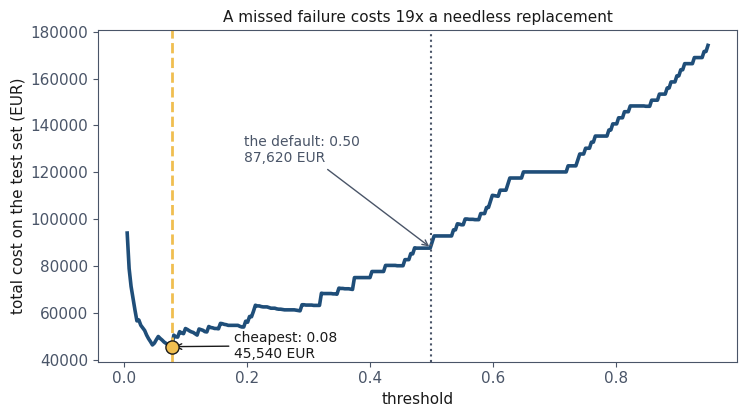

In [8]:
fig, ax = plt.subplots(figsize=(7.6, 4.3))
ax.plot(grid, total_cost, lw=2.6, color=BLUE)
ax.axvline(best_threshold, color=GOLD, ls="--", lw=2)
ax.axvline(0.5, color=SLATE, ls=":", lw=1.5)
ax.scatter([best_threshold], [total_cost.min()], s=90, color=GOLD,
           edgecolor=INK, zorder=5)
ax.annotate(f"cheapest: {best_threshold:.2f}\n{total_cost.min():,} EUR",
            (best_threshold, total_cost.min()), textcoords="offset points",
            xytext=(45, -8), fontsize=10,
            arrowprops=dict(arrowstyle="->", color=INK))
ax.annotate(f"the default: 0.50\n{default_cost:,} EUR", (0.5, default_cost),
            textcoords="offset points", xytext=(-135, 62), fontsize=10,
            color=SLATE, arrowprops=dict(arrowstyle="->", color=SLATE))
ax.set_xlabel("threshold")
ax.set_ylabel("total cost on the test set (EUR)")
ax.set_title(f"A missed failure costs "
             f"{COST_FALSE_NEGATIVE / COST_FALSE_POSITIVE:.0f}x a needless "
             f"replacement", fontsize=11)
fig.tight_layout()
fig.savefig(FIGURES / "cost_curve.png", dpi=150, bbox_inches="tight",
            facecolor="white")
plt.show()

The cheapest threshold is far below 0.5, and that is the general rule rather
than a quirk of these numbers: **when misses cost more than false alarms, the
optimal threshold moves down.** The theory says it should sit near

$$t^* = \frac{C_{FP}}{C_{FP} + C_{FN}}$$

which for €140 and €2,600 is 0.051. Our empirical minimum lands in that
neighbourhood, and the difference is what you would expect from a test set with
76 positives in it — the cost curve is nearly flat around its minimum, so many
thresholds are almost equally good. That flatness is a comfort, not a problem:
it means the exact value does not have to be perfect.

**The honest caveat.** This threshold was chosen by looking at the test set,
which is precisely the sin lesson 1 warned about. Done properly, the threshold
is chosen on a validation set and only then measured on the test set. Lesson 5
builds that machinery; until then, treat this number as a demonstration of the
method rather than a result you could report.

## 5. Class weights: the same idea, applied earlier

Moving the threshold changes the decision after training. **Class weights**
change the training itself, by making each failing drive count as much as many
healthy ones in the loss.

`class_weight="balanced"` weights each class by the inverse of its frequency, so
here each failure counts about 25 times a healthy drive. Compare it against
simply lowering the threshold.

In [9]:
weighted = make_pipeline(
    StandardScaler(), LogisticRegression(max_iter=2_000, class_weight="balanced"))
weighted.fit(X_train, y_train)
weighted_probability = weighted.predict_proba(X_test)[:, 1]
weighted_flagged = (weighted_probability >= 0.5).astype(int)

rows = []
for name, flagged, scores in (
        ("plain, threshold 0.50", default_flagged, probability),
        (f"plain, threshold {best_threshold:.2f}", best_flagged, probability),
        ("balanced weights, 0.50", weighted_flagged, weighted_probability)):
    tn, fp, fn, tp = confusion_matrix(y_test, flagged).ravel()
    rows.append({
        "model": name, "TP": tp, "FP": fp, "FN": fn,
        "precision": precision_score(y_test, flagged, zero_division=0),
        "recall": recall_score(y_test, flagged),
        "AUC": roc_auc_score(y_test, scores),
        "cost EUR": fp * COST_FALSE_POSITIVE + fn * COST_FALSE_NEGATIVE,
    })

print(pd.DataFrame(rows).to_string(index=False,
                                   float_format=lambda v: f"{v:.3f}"))

                 model  TP  FP  FN  precision  recall   AUC  cost EUR
 plain, threshold 0.50  43  13  33      0.768   0.566 0.949     87620
 plain, threshold 0.08  65 121  11      0.349   0.855 0.949     45540
balanced weights, 0.50  68 205   8      0.249   0.895 0.950     49500


Look at the AUC column: **the two models rank almost identically.** Reweighting
did not teach the model anything new about disk failure. What it did was move
where the model puts the 0.5 line — which is the same lever as the threshold,
pulled at a different moment.

That is worth knowing because class weighting is often presented as a cure for
imbalance. It is not a cure; it is a reparameterisation of the same decision.
The cure, if there is one, is more failures to learn from.

**Where it does earn its place:** when a model does not output usable
probabilities, or when a downstream tool insists on `predict()` and gives you no
access to a threshold, weighting is how you move the operating point. And it is
one argument instead of a calibration exercise.

## 6. More than two classes

Real fleets are not healthy-or-dead. A drive can be **degraded**: still
readable, reporting errors, worth replacing at the next maintenance window
rather than at three in the morning.

With three classes the confusion matrix becomes 3×3, and precision and recall
are computed **per class** — for each class in turn, that class is the positive
one and the rest are negative. What changes is how you summarise them.

In [10]:
multi = load_multiclass()
X_multi = transform_features(multi)
y_multi = multi["condition"]
LABELS = ["healthy", "degraded", "failed"]

print(y_multi.value_counts().sort_index().rename(
    index=dict(enumerate(LABELS))).to_string())

Xm_train, Xm_test, ym_train, ym_test = train_test_split(
    X_multi, y_multi, test_size=0.25, random_state=42, stratify=y_multi)

multi_model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=3_000))
multi_model.fit(Xm_train, ym_train)
multi_prediction = multi_model.predict(Xm_test)

print()
print(classification_report(ym_test, multi_prediction,
                            target_names=LABELS, digits=3, zero_division=0))

condition
healthy     6660
degraded    1034
failed       306

              precision    recall  f1-score   support

     healthy      0.927     0.968     0.947      1665
    degraded      0.603     0.498     0.545       259
      failed      0.812     0.513     0.629        76

    accuracy                          0.889      2000
   macro avg      0.781     0.660     0.707      2000
weighted avg      0.881     0.889     0.883      2000



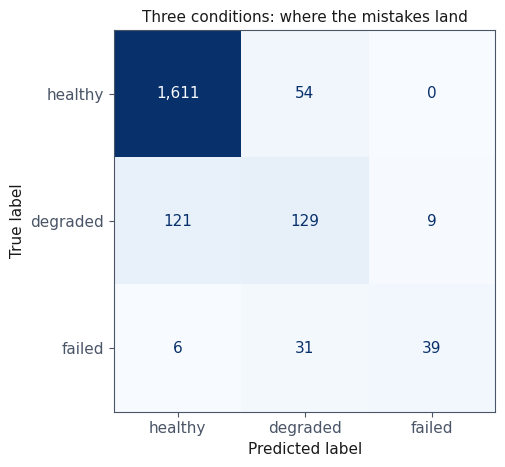

In [11]:
fig, ax = plt.subplots(figsize=(5.6, 4.8))
ConfusionMatrixDisplay.from_predictions(
    ym_test, multi_prediction, ax=ax, colorbar=False, cmap="Blues",
    display_labels=LABELS, values_format=",d")
ax.set_title("Three conditions: where the mistakes land", fontsize=11)
fig.tight_layout()
fig.savefig(FIGURES / "multiclass_confusion.png", dpi=150, bbox_inches="tight",
            facecolor="white")
plt.show()

**Read the off-diagonal cells, not the accuracy.** The matrix says which
confusions the model makes, and they are not symmetric: degraded drives are the
hard class, because they sit between two neighbours that both look like them
from a distance.

**Macro against weighted, one more time.** Macro averaging treats the three
classes as equally important; weighted averaging weights them by how common they
are, so the healthy class — five drives in six — dominates it. On an imbalanced
problem those two numbers can differ by a lot, and quoting the flattering one
without saying which is how a mediocre model gets a good write-up.

Which to use is a question about the application, not about statistics: if
missing a failure matters as much as missing a healthy drive, macro is right.

## What to take away

- The **ROC curve** plots true positive rate against false positive rate as the
  threshold sweeps. The diagonal is guessing; the top-left corner is perfection.
- **AUC is the probability that a random positive outranks a random negative** —
  we verified it by drawing 200,000 pairs. It measures *ranking*, and is blind
  to calibration.
- **AUC hides imbalance.** The false positive rate divides by an enormous
  denominator, so a flood of false alarms barely registers. Report the
  precision-recall curve alongside it.
- **Choose the threshold from costs.** With a miss costing 19 times a false
  alarm, the cheapest threshold was far below 0.5 — and choosing it on purpose
  beat the default by a wide margin.
- **Class weights are the same lever as the threshold**, pulled during training
  instead of after. Note that the AUC barely moved.
- **Multiclass** is per-class precision and recall plus a decision about how to
  average them. Macro treats classes equally; weighted lets the majority speak.

### Homework

`Exercises/04_classification_and_metrics.md`, due **Friday 23 October 2026**. It
asks you to build a classifier on a fresh imbalanced dataset, choose a threshold
from a stated cost ratio, and defend the choice in a short paragraph — the
paragraph being the part that matters.